In [1]:
from sklearn.datasets import make_classification
import numpy as np
X, y = make_classification(n_samples=100, n_features=2, n_informative=1,n_redundant=0,
                           n_classes=2, n_clusters_per_class=1, random_state=41,hypercube=False,class_sep=20)

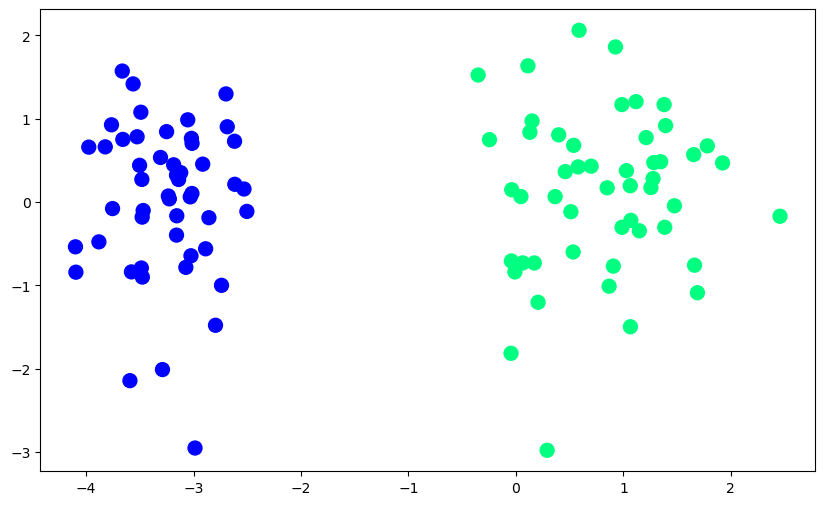

In [2]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.scatter(X[:,0],X[:,1],c=y,cmap='winter',s=100)

In [6]:
from sklearn.linear_model import LogisticRegression
lor = LogisticRegression(penalty=None,solver='sag')
lor.fit(X,y)

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,penalty,None
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'sag'
,max_iter,100
,multi_class,'deprecated'


In [7]:
print(lor.coef_)
print(lor.intercept_)

[[4.78773727 0.20819943]]
[5.75744712]


In [8]:
class LogisticRegressionGradientDescent:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
    def fit(self,X,y):
        X=np.insert(X,0,1,axis=1)
        self.weights=np.ones(X.shape[1])
        for i in range(self.epochs):
            y_pred=self.sigmoid(np.dot(X,self.weights))
            derivativeW=-np.dot(y-y_pred,X)/X.shape[0]
            self.weights=self.weights-self.lr*derivativeW

    def sigmoid(self,x):
        return 1/(1+np.exp(-x))

In [9]:
lr=LogisticRegressionGradientDescent(lr=0.5,epochs=5000)
lr.fit(X,y)
print(lr.weights)


[5.83338865 4.83926872 0.21182255]
